In [1]:
# Step 01: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Prophet version:", Prophet.__version__ if hasattr(Prophet, '__version__') else "Installed")

Prophet version: Installed


In [3]:
# Step 02: Preparing data for Store 1, item 1

In [4]:
df = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])

# Prophet needs exactly two columns: 'ds' and 'y'
subset = df[(df['store'] == 1) & (df['item'] == 1)].copy()
subset = subset[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
subset = subset.sort_values('ds').reset_index(drop=True)

print(f"Total data points: {len(subset)}")
print(f"Date range: {subset['ds'].min()} to {subset['ds'].max()}")
print(subset.head())

Total data points: 1826
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
          ds   y
0 2013-01-01  13
1 2013-01-02  11
2 2013-01-03  14
3 2013-01-04  13
4 2013-01-05  10


In [5]:
# Step 03: Splitting the training and testing data

In [6]:
# Here we need everything before Oct 1, 2017 for training.
# And we will use Oct to Dec 2017 i.e. the last 92 days for testing.

SPLIT_DATE = '2017-10-01'

train = subset[subset['ds'] < SPLIT_DATE].copy()
test  = subset[subset['ds'] >= SPLIT_DATE].copy()

print(f"Training data: {len(train)} rows ({train['ds'].min().date()} to {train['ds'].max().date()})")
print(f"Test data:     {len(test)} rows ({test['ds'].min().date()} to {test['ds'].max().date()})")

Training data: 1734 rows (2013-01-01 to 2017-09-30)
Test data:     92 rows (2017-10-01 to 2017-12-31)


In [7]:
# Step 04: Now we build and train the Prophet

In [9]:
#Building the model
model = Prophet(
    yearly_seasonality  = True,    # Learn annual patterns
    weekly_seasonality  = True,    # Learn day-of-week patterns
    daily_seasonality   = False,   # Not needed (data is already daily aggregated)
    changepoint_prior_scale = 0.05,  # How flexible the trend line is
    seasonality_prior_scale = 10,    # How strong the seasonality is
    interval_width = 0.95            # 95% prediction interval
)

model.add_country_holidays(country_name='US')

#Training the model
print("Training Prophet Model...")
model.fit(train)
print("Training Completed")

Training Prophet Model...


19:42:46 - cmdstanpy - INFO - Chain [1] start processing
19:42:46 - cmdstanpy - INFO - Chain [1] done processing


Training Completed


In [10]:
# Step 05: Making predictions 

In [11]:
#Create a df with future dates(92 days beyond training)

future = model.make_future_dataframe(periods=92)
print(f"Future dataframe shape: {future.shape}")
print(f"Last date in future: {future['ds'].max()}")

# Generating the forecast
forecast = model.predict(future)
print("\nForecast columns:", forecast.columns.tolist())
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

Future dataframe shape: (1826, 1)
Last date in future: 2017-12-31 00:00:00

Forecast columns: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'Christmas Day', 'Christmas Day_lower', 'Christmas Day_upper', 'Christmas Day (observed)', 'Christmas Day (observed)_lower', 'Christmas Day (observed)_upper', 'Columbus Day', 'Columbus Day_lower', 'Columbus Day_upper', 'Independence Day', 'Independence Day_lower', 'Independence Day_upper', 'Independence Day (observed)', 'Independence Day (observed)_lower', 'Independence Day (observed)_upper', 'Labor Day', 'Labor Day_lower', 'Labor Day_upper', 'Martin Luther King Jr. Day', 'Martin Luther King Jr. Day_lower', 'Martin Luther King Jr. Day_upper', 'Memorial Day', 'Memorial Day_lower', 'Memorial Day_upper', "New Year's Day", "New Year's Day_lower", "New Year's Day_upper", "New Year's Day (observed)", "New Year's Day (observed)_lower", "New Year's Day (observed)_upper", 'Thanksgiving Day', 'Thanksgiving Day_lower', 'Thanksgivin

In [12]:
# Step 06: Plotting the forecast

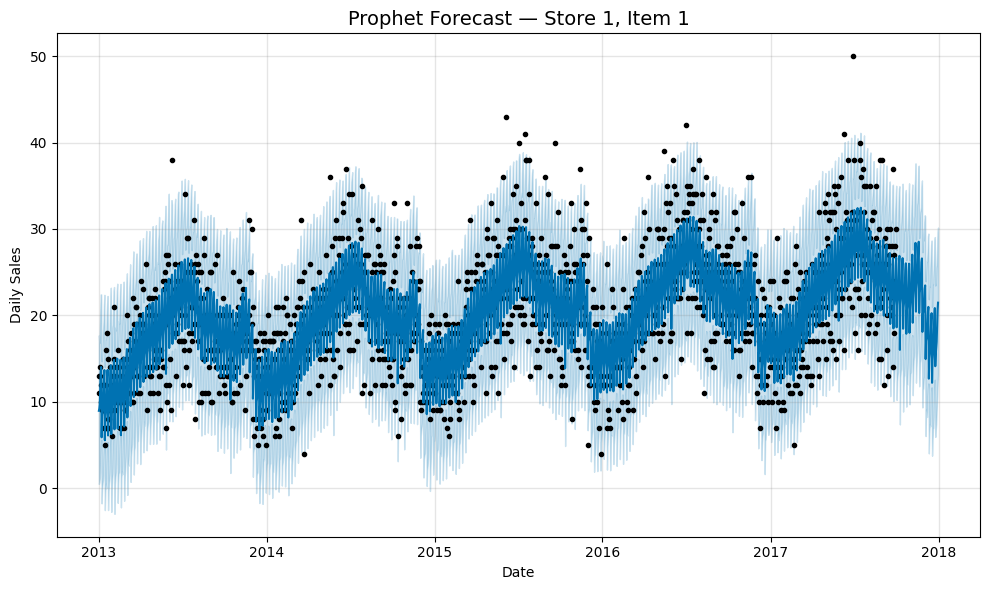

The shaded area = 95% confidence interval (where we expect actual sales to fall)


In [13]:
fig1 = model.plot(forecast)
plt.title('Prophet Forecast — Store 1, Item 1', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.tight_layout()
plt.savefig('../results/prophet_forecast.png', dpi=150)
plt.show()
print("The shaded area = 95% confidence interval (where we expect actual sales to fall)")

In [14]:
#Step 07: Plot the components

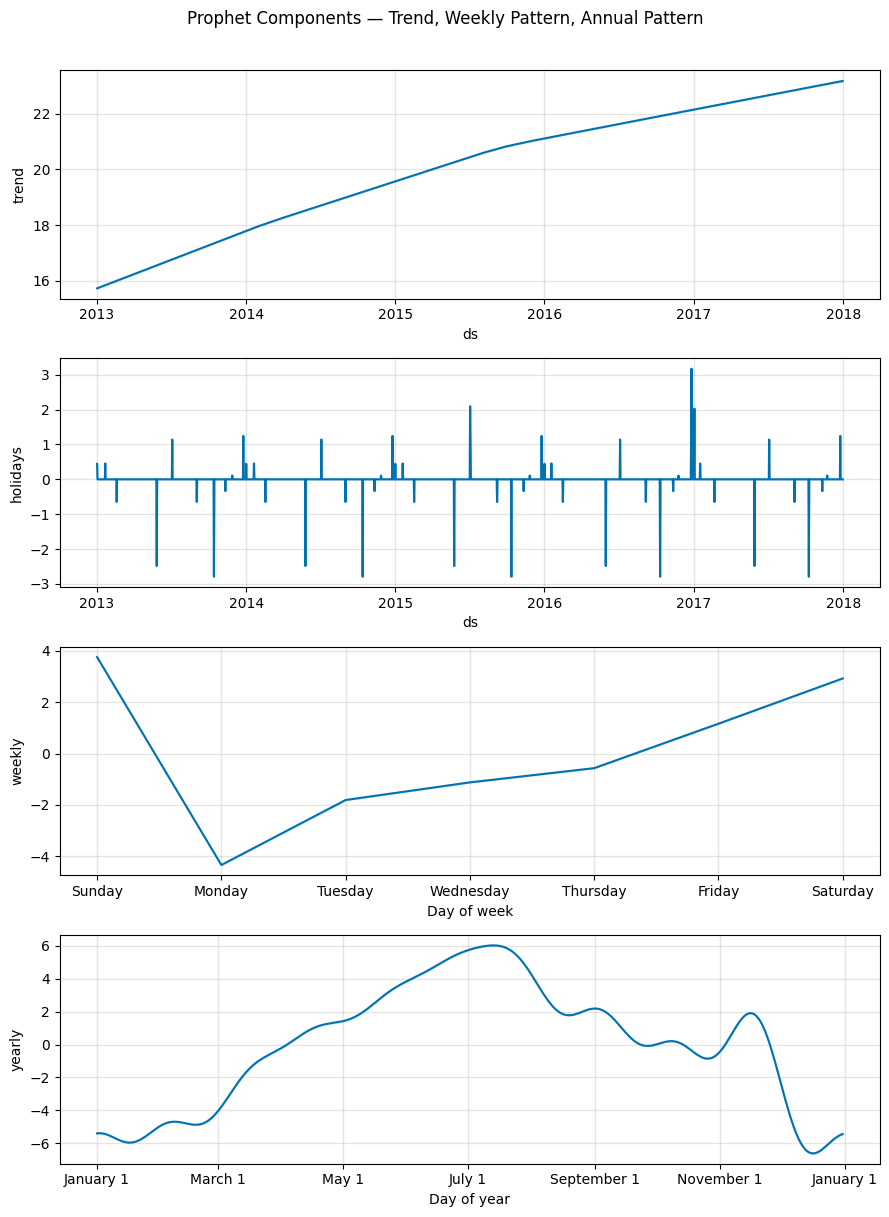

In [15]:
fig2 = model.plot_components(forecast)
plt.suptitle('Prophet Components — Trend, Weekly Pattern, Annual Pattern', y=1.01)
plt.tight_layout()
plt.savefig('../results/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
#Step 08: Evaluate the accuracy

In [17]:
# Get Prophet's predictions for test period only
test_forecast = forecast[forecast['ds'].isin(test['ds'])].copy()
test_merged   = test.merge(test_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# No negative predictions
test_merged['yhat'] = test_merged['yhat'].clip(lower=0)

# Calculating the metrics
mae  = mean_absolute_error(test_merged['y'], test_merged['yhat'])
rmse = np.sqrt(mean_squared_error(test_merged['y'], test_merged['yhat']))
mape = (abs(test_merged['y'] - test_merged['yhat']) / (test_merged['y'] + 1e-5)).mean() * 100

print("=" * 40)
print("PROPHET MODEL RESULTS — Store 1, Item 1")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error):            {mae:.2f} units")
print(f"  RMSE (Root Mean Squared Error):        {rmse:.2f} units")
print(f"  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print("=" * 40)
print(f"\nInterpretation: On average, the Prophet forecast is {mape:.1f}% off from actual sales.")

PROPHET MODEL RESULTS — Store 1, Item 1
  MAE  (Mean Absolute Error):            3.79 units
  RMSE (Root Mean Squared Error):        4.58 units
  MAPE (Mean Absolute Percentage Error): 23.49%

Interpretation: On average, the Prophet forecast is 23.5% off from actual sales.


In [18]:
#Step 09: Plotting Actual vs. Predicted

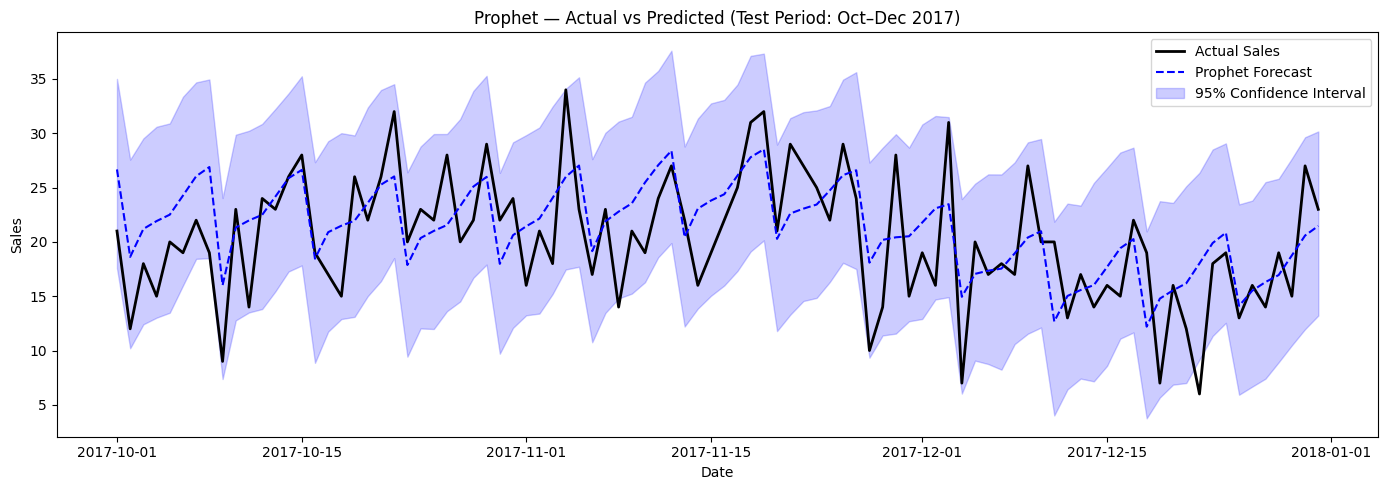

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(test_merged['ds'], test_merged['y'],    label='Actual Sales',     color='black',  linewidth=2)
plt.plot(test_merged['ds'], test_merged['yhat'], label='Prophet Forecast', color='blue',   linewidth=1.5, linestyle='--')
plt.fill_between(
    test_merged['ds'],
    test_merged['yhat_lower'],
    test_merged['yhat_upper'],
    alpha=0.2, color='blue', label='95% Confidence Interval'
)
plt.title('Prophet — Actual vs Predicted (Test Period: Oct–Dec 2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../results/prophet_vs_actual.png', dpi=150)
plt.show()